# Latent-bridge v2 — a more varied two-hop swap set, filtered on GPT-2 XL

Can we build a latent-bridge set with more varied prompts than landmarks alone, on which GPT-2 XL
gets the unpatched answer right by construction? `latent-bridge.json` asks for the language of a
landmark's country without naming the country; GPT-2 XL answers 71% of it, and almost all errors
are factual (another language), mostly where the model does not know the landmark's country.
Here the subject is a landmark, a city, a person, a company, or a food/drink; the bridge is
still a country that the prompt never names, and the answer is its main language.

**Answer (this run).** Yes. Of 530 candidates in five families, 354 subjects pass the filter
(1416 swap items): 98 cities, 83 people, 71 landmarks, 53 foods/drinks and 49 companies, over all
22 countries. GPT-2 XL knows the language of every country (hop 2: 22/22). Subjects are lost at
hop 1 (82 subjects whose country it does not know, mostly foods and companies) and at composition
(94 subjects with both hops known but the wrong language, mostly ` English` or ` Mandarin`).

## Method

**Candidates.** `data/experiments/latent-bridge-v2-candidates.json`: five subject families, 22
countries (the 20 of `latent-bridge` plus Sweden and Korea), one prompt template per family
(*"Toyota is a company from a country where the main language is"*) and one hop-1 template
(*"Toyota is a company based in the country of"*). Subjects whose name contains a country or a
language of the set (e.g. *Turkish Airlines*) are dropped: they would name the bridge or the
answer.

**Filter.** One batched GPT-2 XL pass (fp32, `<|endoftext|>` prepended as BOS, right padding,
read at the last real token) per prompt kind. A subject is kept when all three hold:

1. *hop 1*: on the hop-1 prompt, the subject's country has the highest logit among the 22
   countries (best single-token spelling);
2. *hop 2*: on *"The main language of {country} is"*, the country's language has the highest
   logit among the 19 languages (Spanish and Portuguese are shared);
3. *composed*: the greedy next token of the two-hop prompt is a spelling of the language
   (`jlens.evaluation.spelling_ids`), the same baseline criterion as `concept_swap.ipynb`.

Hops 1–2 use a choice among candidates rather than greedy top-1, so a format token (` the`,
` Mandarin`) does not count as not knowing. Criterion 3 is strict: *Mandarin* is not accepted
for *Chinese*, so that `concept_swap.ipynb` scores the kept trials as correct without aliases.

**Swap items.** As in `latent-bridge`: each kept subject gets 4 swap countries with a different
language, drawn with `random.Random(0)` from the countries that pass hop 2.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "readout_cache.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.nn.utils.rnn import pad_sequence
from transformers import AutoModelForCausalLM, AutoTokenizer

from jlens.evaluation import spelling_ids

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", None)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / "gpt2-xl"))
RUN_DIR.mkdir(parents=True, exist_ok=True)
CACHE = RUN_DIR / "latent_bridge_v2_filter.csv"
HOP2_CACHE = RUN_DIR / "latent_bridge_v2_hop2.csv"
CANDIDATES = Path(REPO_DIR) / "data/experiments/latent-bridge-v2-candidates.json"
OUT_PATH = Path(REPO_DIR) / "data/experiments/latent-bridge-v2.json"
N_SWAPS = 4
SEED = 0
BATCH_SIZE = 64  # prompts per forward pass

## 1. Candidates

In [4]:
pool = json.loads(CANDIDATES.read_text())
LANG = pool["languages"]
COUNTRIES = list(LANG)
LANGUAGES = sorted(set(LANG.values()))
FAMILIES = list(pool["families"])
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)


def sentence(template, subject):
    text = template.format(X=subject)
    return text[0].upper() + text[1:]


cands = pd.DataFrame([
    {"family": family, "subject": subject, "country": country, "answer": LANG[country],
     "prompt": sentence(spec["template"], subject), "hop1_prompt": sentence(spec["hop1_template"], subject)}
    for family, spec in pool["families"].items()
    for country, subjects in spec["subjects"].items()
    for subject in subjects
])
NAMES = [word.lower() for word in COUNTRIES + LANGUAGES]
cands["leak"] = cands.subject.str.lower().map(lambda s: any(name in s for name in NAMES))
assert all(len(tokenizer.encode(" " + c)) == 1 for c in COUNTRIES), "every country must be one token"
assert all(spelling_ids(tokenizer, lang) for lang in LANGUAGES)
print(f"{len(cands)} candidates, {len(COUNTRIES)} countries, {len(LANGUAGES)} languages")
display(cands.groupby("family", sort=False).agg(candidates=("subject", "size"), countries=("country", "nunique"),
                                                 leaking=("leak", "sum")))
display(cands[cands.leak][["family", "subject", "country"]])
cands = cands[~cands.leak].reset_index(drop=True)
cands.groupby("family", sort=False).head(1)[["family", "prompt", "hop1_prompt", "answer"]]

530 candidates, 22 countries, 19 languages


,candidates,countries,leaking
family,,,
landmark,108,22,0
city,119,22,0
person,117,22,0
brand,83,20,0
food,103,21,0


,family,subject,country


,family,prompt,hop1_prompt,answer
0,landmark,The Eiffel Tower is in a country where the main language is,The Eiffel Tower is located in the country of,French
108,city,Lyon is a city in a country where the main language is,Lyon is a city in the country of,French
227,person,Napoleon was born in a country where the main language is,Napoleon was born in the country of,French
344,brand,Renault is a company from a country where the main language is,Renault is a company based in the country of,French
427,food,Croissant comes from a country where the main language is,Croissant comes from the country of,French


## 2. Model passes

Three batched readouts: hop 1 (22 countries as options), hop 2 (21 languages, one prompt per
country) and the composed prompt (19 languages). Cached to `CACHE` / `HOP2_CACHE` and skipped
when both exist (the model is then not loaded).

In [5]:
need_run = not (CACHE.exists() and HOP2_CACHE.exists())
if need_run:
    hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE).eval()


def spelling_index(words):
    # [n, K] spelling ids per word, padded by repeating each row's first id.
    rows = [sorted(spelling_ids(tokenizer, word)) for word in words]
    width = max(map(len, rows))
    return torch.tensor([row + row[:1] * (width - len(row)) for row in rows], device=DEVICE)


@torch.no_grad()
def readout(prompts, answers, options):
    """Per prompt: greedy top-1 is a spelling of its answer; best-scoring option; top-1 token."""
    index = spelling_index(options)
    position = {option: i for i, option in enumerate(options)}
    encoded = [[tokenizer.bos_token_id, *tokenizer(p).input_ids] for p in prompts]
    order = sorted(range(len(prompts)), key=lambda i: len(encoded[i]))
    greedy = np.zeros(len(prompts), bool)
    chosen = np.zeros(len(prompts), int)
    top1 = np.zeros(len(prompts), int)
    for start in range(0, len(order), BATCH_SIZE):
        rows = order[start:start + BATCH_SIZE]
        ids = pad_sequence([torch.tensor(encoded[i]) for i in rows], batch_first=True,
                           padding_value=tokenizer.eos_token_id).to(DEVICE)
        last = torch.tensor([len(encoded[i]) - 1 for i in rows], device=DEVICE)
        logits = hf_model(input_ids=ids).logits[torch.arange(len(rows), device=DEVICE), last].float()
        best = logits.argmax(1)
        answer = index[torch.tensor([position[answers[i]] for i in rows], device=DEVICE)]
        hit = (answer == best[:, None]).any(1)
        scores = logits[:, index].max(-1).values  # [batch, n_options]
        out = torch.stack([hit.long(), scores.argmax(1), best]).cpu().numpy()  # one sync per batch
        greedy[rows], chosen[rows], top1[rows] = out[0].astype(bool), out[1], out[2]
    return greedy, [options[i] for i in chosen], [tokenizer.decode(int(t)) for t in top1]


if need_run:
    filt = cands[["family", "subject", "country", "answer"]].copy()
    _, filt["hop1_choice"], filt["hop1_top1"] = readout(list(cands.hop1_prompt), list(cands.country), COUNTRIES)
    filt["base_correct"], filt["base_choice"], filt["base_top1"] = readout(
        list(cands.prompt), list(cands.answer), LANGUAGES)
    hop2 = pd.DataFrame({"country": COUNTRIES, "answer": [LANG[c] for c in COUNTRIES]})
    hop2["greedy"], hop2["choice"], hop2["top1"] = readout(
        [pool["hop2_template"].format(country=c) for c in COUNTRIES], list(hop2.answer), LANGUAGES)
    filt.to_csv(CACHE, index=False)
    hop2.to_csv(HOP2_CACHE, index=False)
    (RUN_DIR / "latent_bridge_v2_run.json").write_text(json.dumps(
        {"model_id": MODEL_ID, "dtype": str(DTYPE), "bos": "<|endoftext|>", "batch_size": BATCH_SIZE}, indent=1))
else:
    print("loaded caches", CACHE, HOP2_CACHE)
filt = pd.read_csv(CACHE, keep_default_na=False)
filt["base_correct"] = filt.base_correct.astype(str).eq("True")
hop2 = pd.read_csv(HOP2_CACHE, keep_default_na=False)
hop2["greedy"] = hop2.greedy.astype(str).eq("True")

loaded caches /workspace/runs/latent-bridge-v2/latent_bridge_v2_filter.csv /workspace/runs/latent-bridge-v2/latent_bridge_v2_hop2.csv


## 3. Filter

### Hop 2: does GPT-2 XL know each country's language?

In [6]:
hop2["known"] = hop2.choice.eq(hop2.answer)
KNOWN = set(hop2.country[hop2.known])
print(f"{len(KNOWN)} of {len(hop2)} countries pass hop 2")
hop2[~hop2.known | ~hop2.greedy][["country", "answer", "top1", "choice"]]

22 of 22 countries pass hop 2


,country,answer,top1,choice
6,China,Chinese,Mandarin,Chinese


### Funnel by family

In [7]:
filt["hop1_ok"] = filt.hop1_choice.eq(filt.country)
filt["hop2_ok"] = filt.country.isin(KNOWN)
filt["kept"] = filt.hop1_ok & filt.hop2_ok & filt.base_correct
funnel = filt.groupby("family", sort=False).agg(
    candidates=("subject", "size"), hop1=("hop1_ok", "sum"), hop1_and_hop2=("hop2_ok", lambda s: (s & filt.hop1_ok[s.index]).sum()),
    composed=("base_correct", "sum"), kept=("kept", "sum"))
funnel.loc["total"] = funnel.sum()
funnel["composed accuracy"] = (funnel.composed / funnel.candidates).round(2)
funnel["kept share"] = (funnel.kept / funnel.candidates).round(2)
funnel

,candidates,hop1,hop1_and_hop2,composed,kept,composed accuracy,kept share
family,,,,,,,
landmark,108,90,90,74,71,0.69,0.66
city,119,116,116,99,98,0.83,0.82
person,117,103,103,89,83,0.76,0.71
brand,83,68,68,53,49,0.64,0.59
food,103,71,71,61,53,0.59,0.51
total,530,448,448,376,354,0.71,0.67


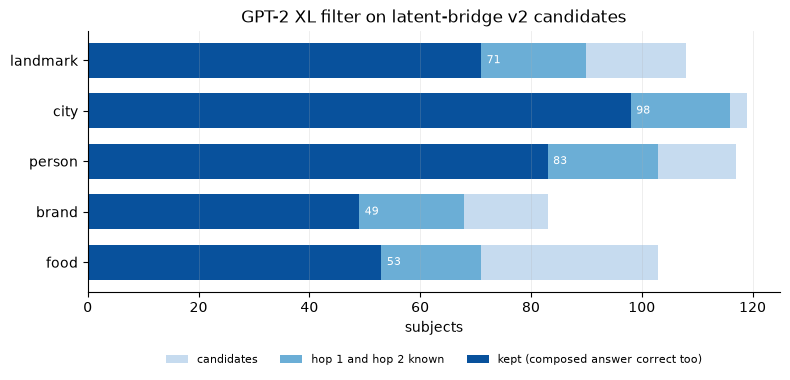

In [8]:
stages = ["candidates", "hop1_and_hop2", "kept"]
labels = ["candidates", "hop 1 and hop 2 known", "kept (composed answer correct too)"]
colors = ["#c6dbef", "#6baed6", "#08519c"]
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(FAMILIES))
for stage, label, color in zip(stages, labels, colors, strict=True):
    ax.barh(y, funnel.loc[FAMILIES, stage], color=color, label=label, height=0.7)
for i, family in enumerate(FAMILIES):
    ax.text(funnel.loc[family, "kept"] + 1, i, int(funnel.loc[family, "kept"]), va="center", color="white"
            if funnel.loc[family, "kept"] > 15 else "black", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(FAMILIES)
ax.invert_yaxis()
ax.set_xlabel("subjects")
ax.set_title("GPT-2 XL filter on latent-bridge v2 candidates")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
ax.grid(axis="x", alpha=0.25, lw=0.6)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### Composed accuracy given the hops

If GPT-2 XL knows both hops, how often does it compose them? Rows: hop 1 known or not (among
subjects whose country passes hop 2).

In [9]:
known_hop2 = filt[filt.hop2_ok]
pd.crosstab([known_hop2.family, known_hop2.hop1_ok], known_hop2.base_correct, margins=False).rename(
    columns={False: "composed wrong", True: "composed right"})

base_correct      composed wrong  composed right
family   hop1_ok                                
brand    False                11               4
         True                 19              49
city     False                 2               1
         True                 18              98
food     False                24               8
         True                 18              53
landmark False                15               3
         True                 19              71
person   False                 8               6
         True                 20              83

### What the model says when it fails

Greedy top-1 on the composed prompt for subjects that pass both hops but fail the composition,
and the most frequent wrong tokens per family.

In [10]:
failed = filt[filt.hop1_ok & filt.hop2_ok & ~filt.base_correct]
display(failed.groupby("family", sort=False).base_top1.agg(
    lambda s: ", ".join(f"{t!r}×{n}" for t, n in s.value_counts().head(6).items())).to_frame("top wrong tokens"))
failed.groupby("family", sort=False).head(5)[["family", "subject", "country", "answer", "base_top1", "base_choice"]]

,top wrong tokens
family,
landmark,"' English'×8, ' Arabic'×6, ' Russian'×2, ' not'×1, ' Hindi'×1, ' Aram'×1"
city,"' Mandarin'×6, ' Arabic'×3, ' English'×2, ' French'×1, ' Catalan'×1, ' Beng'×1"
person,"' English'×13, ' French'×2, ' Latin'×1, ' Mandarin'×1, ' Greek'×1, ' Russian'×1"
brand,"' English'×12, ' Spanish'×2, ' French'×2, ' Mandarin'×1, ' Arabic'×1, ' Russian'×1"
food,"' English'×4, ' Cant'×3, ' Ur'×2, ' Arabic'×2, ' Turkish'×2, ' not'×1"


,family,subject,country,answer,base_top1,base_choice
8,landmark,the Trevi Fountain,Italy,Italian,Arabic,Arabic
9,landmark,St. Mark's Basilica,Italy,Italian,Arabic,Arabic
37,landmark,the Great Wall,China,Chinese,English,English
39,landmark,Tiananmen Square,China,Chinese,not,English
41,landmark,the Summer Palace,China,Chinese,English,English
117,city,Florence,Italy,Italian,French,French
120,city,Barcelona,Spain,Spanish,Catalan,Spanish
144,city,Shanghai,China,Chinese,Mandarin,Chinese
145,city,Guangzhou,China,Chinese,Mandarin,Chinese
146,city,Shenzhen,China,Chinese,Mandarin,English


Subjects whose country GPT-2 XL does not know (hop 1), by family:

In [11]:
wrong_hop1 = filt[~filt.hop1_ok]
wrong_hop1.groupby("family", sort=False).apply(
    lambda f: ", ".join(f"{s} → {c}" for s, c in zip(f.subject, f.hop1_choice, strict=True)), include_groups=False
).to_frame("subject → chosen country")

,subject → chosen country
family,
landmark,"Park Guell → Korea, St. Basil's Cathedral → Greece, the Golden Pavilion → China, Qutub Minar → Turkey, the Valley of the Kings → China, Karnak Temple → India, Ephesus → Greece, the Grand Bazaar → India, Christ the Redeemer → Mexico, Sugarloaf Mountain → Mexico, the Anne Frank House → Israel, Keukenhof Gardens → Germany, the Van Gogh Museum → France, the Belem Tower → Brazil, Jeronimos Monastery → Greece, Pena Palace → Spain, Malbork Castle → Sweden, Bulguksa Temple → Turkey"
city,"Kazan → Turkey, Corinth → Egypt, Faro → Spain"
person,"Bismarck → Sweden, Homer → Israel, Winston Churchill → India, Suleiman the Magnificent → Egypt, Johan Cruyff → Spain, Vermeer → Germany, Erasmus → France, Magellan → Mexico, Fernando Pessoa → Brazil, Diego Rivera → Spain, Tony Jaa → Korea, Copernicus → Italy, Mario Vargas Llosa → Mexico, Greta Garbo → Poland"
brand,"Armani → Turkey, Zara → Turkey, Seat → Israel, Telefonica → Mexico, Aegean Airlines → Turkey, Jaguar → India, Burberry → France, Beko → Japan, Philips → Germany, Corona → Spain, Bimbo → Brazil, Singha → India, Chang → China, Orlen → Sweden, Electrolux → Germany"
food,"churros → Mexico, borscht → Poland, blini → India, pelmeni → Greece, caviar → Spain, kung pao chicken → Thailand, chai → China, koshari → Japan, ful medames → Brazil, molokhia → Russia, souvlaki → Turkey, roast beef → Turkey, scones → Italy, baklava → Greece, raki → Japan, feijoada → Spain, pao de queijo → Portugal, stroopwafel → Germany, Gouda cheese → France, Edam cheese → France, poffertjes → Portugal, pastel de nata → Spain, bacalhau → Brazil, green curry → India, bigos → Greece, zurek → India, ceviche → Spain, pisco → Spain, lomo saltado → Spain, cuy → Spain, gravlax → Japan, kanelbulle → India"


## 4. Swap items

In [12]:
rng = random.Random(SEED)
templates = {family: spec["template"] for family, spec in pool["families"].items()}
prompts = dict(zip(zip(cands.family, cands.subject, strict=True), cands.prompt, strict=True))
targets_by_language = {lang: [c for c in COUNTRIES if c in KNOWN and LANG[c] != lang] for lang in LANGUAGES}
items = []
for row in filt[filt.kept].itertuples():
    for target in rng.sample(targets_by_language[row.answer], N_SWAPS):
        items.append({"name": f"{row.subject}:{row.country}->{target}", "family": row.family,
                      "category": row.country, "subject": row.subject,
                      "prompt": prompts[row.family, row.subject], "intermediate": row.country,
                      "answer": row.answer, "swap_to": target, "swap_answer": LANG[target]})
items_df = pd.DataFrame(items)
assert items_df.name.is_unique
header = {"model": MODEL_ID, "dtype": "float32", "bos": "<|endoftext|>",
          "filter": "hop-1 country and hop-2 language best among candidates; greedy composed answer correct"}
with open(OUT_PATH, "w") as f:
    f.write("{\n")
    f.write(f' "filtered_on": {json.dumps(header)},\n')
    f.write(f' "templates": {json.dumps(templates)},\n')
    f.write(f' "languages": {json.dumps(LANG)},\n')
    f.write(' "items": [\n')
    f.write(",\n".join(f"  {json.dumps(item)}" for item in items))
    f.write("\n ]\n}\n")
assert json.loads(OUT_PATH.read_text())["items"] == items
print(f"wrote {OUT_PATH.name}: {items_df.subject.nunique()} subjects, {len(items)} swap items")
display(items_df.drop_duplicates(["family", "subject"]).pivot_table(
    index="category", columns="family", values="subject", aggfunc="size", fill_value=0)[FAMILIES])
items_df.groupby("family", sort=False).head(1)[["name", "prompt", "answer", "swap_answer"]]

wrote latent-bridge-v2.json: 354 subjects, 1416 swap items


family,landmark,city,person,brand,food
category,,,,,
Brazil,3,6,5,2,2
China,3,0,1,1,0
Egypt,4,5,5,0,0
England,6,6,5,4,3
France,6,6,7,7,7
Germany,6,6,5,7,4
Greece,4,3,4,0,1
India,4,3,4,2,3
Israel,1,1,5,0,0


,name,prompt,answer,swap_answer
0,the Eiffel Tower:France->Netherlands,The Eiffel Tower is in a country where the main language is,French,Dutch
284,Lyon:France->Spain,Lyon is a city in a country where the main language is,French,Spanish
676,Napoleon:France->Mexico,Napoleon was born in a country where the main language is,French,Spanish
1008,Renault:France->Japan,Renault is a company from a country where the main language is,French,Japanese
1204,croissant:France->Thailand,Croissant comes from a country where the main language is,French,Thai


## 5. Conclusions

* **The set is 4.5× larger and five times more varied than `latent-bridge`.** 354 subjects in five
  families pass all three checks, so the unpatched GPT-2 XL answer is correct on every item by
  construction (under the `concept_swap.ipynb` scoring), and the bridge country is one the model
  can name from the subject.
* **Hop 2 is never the bottleneck; hop 1 and composition are.** All 22 country→language facts
  are known. Hop 1 fails for 82 of 530 subjects: foods (32) and companies (15) most often, cities
  only 3. With both hops known, the composed answer is right for 84% of cities, 81% of people,
  79% of landmarks, 75% of foods and 72% of companies.
* **Right answers without hop 1 are excluded.** 22 subjects get the language right although the
  model picks the wrong country for them; they are dropped because the bridge may be absent.
* **Failure modes when both hops are known:** a default ` English` (people and companies: Mao
  Zedong, Sony, Adidas), ` Mandarin` / ` Cantonese` for Chinese, and cultural associations
  (Trevi Fountain → Arabic, Gucci and Prada → French, Galileo → Latin, Barcelona → Catalan).
* **Countries are unbalanced.** France has 33 subjects, China 5 (strict scoring rejects
  *Mandarin*), Thailand 4; swap targets are drawn uniformly over the 22 countries. Compare swap
  success per family or per country rather than only pooled.
* **Next:** run the J-lens / logit / probe / random swaps of `concept_swap.ipynb` on this set and
  compare families.